# BB-code depolarizing-noise Monte Carlo for BPOSD-0

This notebook is set up to reproduce the **BPOSD-0** curves in **Figure 9** of
[*The closed-branch decoder for quantum LDPC codes*](https://arxiv.org/abs/2402.01532) for the three standard
BB codes:
- `[[72,12,6]]`
- `[[108,8,10]]`
- `[[144,12,12]]`

Noise model:
- **pure data-qubit depolarizing noise**
- each qubit receives `X`, `Y`, or `Z` with probability `p/3` each

Decoder:
- **BP+OSD-0** implemented through `bp_osd_cs_decode(...; osd_order=0)`
- binary CSS decoding of the `X` and `Z` sectors separately, with marginal prior `2p/3` in each sector

For the pure data-qubit model, a trial is counted as a failure iff the residual
Pauli error is nontrivial modulo the CSS stabilizer groups.

Conclusion
- The [[72,12,6]] code gives similar results, but the results for the other two codes are quite different
- This may be attributed to the fact that the decoders are not exactly the same


In [1]:
using Plots
using Distributed
using LinearAlgebra
using JLD2

num_cores = length(Sys.cpu_info())
if nprocs() == 1
    addprocs(num_cores; exeflags=`--project=$(Base.active_project())`)
end

@everywhere begin
    using LatticeAlgorithms
    using LinearAlgebra
    using Random
    using Dates
end

println("num_cores = $(num_cores)")


[ Info: Precompiling LatticeAlgorithms [a78adfda-4fd7-4d44-a8dc-283d2f23e82b]
  ** incremental compilation may be fatally broken for this module **

┌ Warning: Replacing docs for `LatticeAlgorithms.get_grid_points_2D_lattice :: Tuple{Matrix, Number, Number}` in module `LatticeAlgorithms`
└ @ Base.Docs docs/Docs.jl:240
  ** incremental compilation may be fatally broken for this module **

┌ Warning: Replacing docs for `LatticeAlgorithms.basis_transformation :: Tuple{Integer}` in module `LatticeAlgorithms`
└ @ Base.Docs docs/Docs.jl:240
  ** incremental compilation may be fatally broken for this module **

┌ Warning: Replacing docs for `LatticeAlgorithms.canonical_form_of_anti_symmetric_matrix :: Tuple{Matrix}` in module `LatticeAlgorithms`
└ @ Base.Docs docs/Docs.jl:240
  ** incremental compilation may be fatally broken for this module **

  ** incremental compilation may be fatally broken for this module **

  ** incremental compilation may be fatally broken for this module **

  ** in

      From worker 6:	┌ Info: CondaPkg: Waiting for lock to be freed. You may delete this file if no other process is resolving.
      From worker 6:	└   lock_file = "/Users/maolinml/Documents/Research/LatticeAlgorithms.jl_github/LatticeAlgorithms.jl/.CondaPkg/lock"
      From worker 3:	┌ Info: CondaPkg: Waiting for lock to be freed. You may delete this file if no other process is resolving.
      From worker 3:	└   lock_file = "/Users/maolinml/Documents/Research/LatticeAlgorithms.jl_github/LatticeAlgorithms.jl/.CondaPkg/lock"
      From worker 2:	┌ Info: CondaPkg: Waiting for lock to be freed. You may delete this file if no other process is resolving.
      From worker 2:	└   lock_file = "/Users/maolinml/Documents/Research/LatticeAlgorithms.jl_github/LatticeAlgorithms.jl/.CondaPkg/lock"
      From worker 9:	┌ Info: CondaPkg: Waiting for lock to be freed. You may delete this file if no other process is resolving.
      From worker 9:	└   lock_file = "/Users/maolinml/Documents/Research/L

In [2]:
num_super_samples = 1
num_samples = Int(2e4)

num_samples_each_core = Int(ceil(num_samples / num_cores))
num_total_samples = Int(num_samples_each_core * num_cores)
println([num_samples_each_core, num_samples, num_total_samples])


p_range = exp10.(range(log10(0.01), log10(0.15), length=16))

function get_bb_spec(type_lattice::String)
    if type_lattice == "bb_72_12_6"
        return (
            label = "[[72,12,6]]",
            l = 6,
            m = 6,
            A_terms = [(:x, 3), (:y, 1), (:y, 2)],
            B_terms = [(:y, 3), (:x, 1), (:x, 2)],
        )
    elseif type_lattice == "bb_108_8_10"
        return (
            label = "[[108,8,10]]",
            l = 9,
            m = 6,
            A_terms = [(:x, 3), (:y, 1), (:y, 2)],
            B_terms = [(:y, 3), (:x, 1), (:x, 2)],
        )
    elseif type_lattice == "bb_144_12_12"
        return (
            label = "[[144,12,12]]",
            l = 12,
            m = 6,
            A_terms = [(:x, 3), (:y, 1), (:y, 2)],
            B_terms = [(:y, 3), (:x, 1), (:x, 2)],
        )
    else
        error("Unsupported type_lattice = $type_lattice")
    end
end

[2500, 20000, 20000]


get_bb_spec (generic function with 1 method)

In [3]:
@everywhere begin

    function sample_depolarizing_binary(n::Int, p::Float64)
        ex = zeros(Int64, n)
        ez = zeros(Int64, n)
        third = p / 3
        twothird = 2p / 3
        for i in 1:n
            r = rand()
            if r < third
                ex[i] = 1                    # X
            elseif r < twothird
                ez[i] = 1                    # Z
            elseif r < p
                ex[i] = 1                    # Y
                ez[i] = 1
            end
        end
        return ex, ez
    end

    function residual_is_trivial_css(ex::AbstractVector{<:Integer}, ez::AbstractVector{<:Integer},
                                     RX::AbstractMatrix{<:Integer}, pivX::AbstractVector{<:Integer},
                                     RZ::AbstractMatrix{<:Integer}, pivZ::AbstractVector{<:Integer})
        return gf2_in_rowspace(ex, RZ, pivZ) && gf2_in_rowspace(ez, RX, pivX)
    end
end


## [[72,12,6]]

In [4]:
type_lattice = "bb_72_12_6"

function run_type_lattice(type_lattice)

    spec = get_bb_spec(type_lattice)
    println(spec)

    logfile = "$(type_lattice)_bposd0_$(p_range[1])_$(p_range[end])_$(num_total_samples)_log.txt"
    open(logfile, "w") do file
    end

    @time results = pmap(1:num_cores) do _
        p_list = Dict(p_range .=> [0.0 for _ in 1:length(p_range)])
        t_list = Dict(p_range .=> [0.0 for _ in 1:length(p_range)])
        xconv_list = Dict(p_range .=> [0.0 for _ in 1:length(p_range)])
        zconv_list = Dict(p_range .=> [0.0 for _ in 1:length(p_range)])

        HX, HZ = bb_check_matrices(spec.l, spec.m, spec.A_terms, spec.B_terms)
        HX = Int64.(HX)
        HZ = Int64.(HZ)
        n = size(HX, 2)

        RX, pivX = gf2_rref(HX)
        RZ, pivZ = gf2_rref(HZ)

        for (ind_p, p) in enumerate(p_range)
            p_success = 0
            time_decode = 0.0
            xconv = 0
            zconv = 0

            ptime = @elapsed for _ in 1:num_samples_each_core
                ex, ez = sample_depolarizing_binary(n, p)

                sx = mod.(HZ * ex, 2)
                sz = mod.(HX * ez, 2)

                q = 2p / 3

                elapsed = @elapsed begin
                    x_result = bp_osd_cs_decode(HZ, sx, q; osd_order=0)
                    z_result = bp_osd_cs_decode(HX, sz, q; osd_order=0)
                end
                time_decode += elapsed

                xconv += x_result.converged ? 1 : 0
                zconv += z_result.converged ? 1 : 0

                rex = mod.(ex .+ x_result.error, 2)
                rez = mod.(ez .+ z_result.error, 2)

                if residual_is_trivial_css(rex, rez, RX, pivX, RZ, pivZ)
                    p_success += 1
                end
            end

            p_list[p] += p_success
            t_list[p] += time_decode
            xconv_list[p] += xconv
            zconv_list[p] += zconv

            if myid() == 2
                println(["$(ind_p)/$(length(p_range)), p=$(p), $(ptime), $(string(now()))"])
                open(logfile, "a") do file
                    write(file, "$(ind_p)/$(length(p_range)), p=$(p), $(ptime), $(string(now()))\n")
                end
            end
        end

        return p_list, t_list, xconv_list, zconv_list
    end

    p_success_list = merge(+, [res[1] for res in results]...)
    t_list = merge(+, [res[2] for res in results]...)
    xconv_list = merge(+, [res[3] for res in results]...)
    zconv_list = merge(+, [res[4] for res in results]...)

    map!(v -> v ./ num_total_samples, values(p_success_list))
    map!(v -> v ./ num_total_samples, values(t_list))
    map!(v -> v ./ num_total_samples, values(xconv_list))
    map!(v -> v ./ num_total_samples, values(zconv_list))

    p_fail_list = Dict(p => 1 .- p_success_list[p] for p in p_range)

    fn = "$(type_lattice)_bposd0_$(p_range[1])_$(p_range[end])_$(num_total_samples).jld2"
    jldsave(fn;
        type_lattice = type_lattice,
        label = spec.label,
        p_range = p_range,
        num_samples = num_total_samples,
        p_success_list = p_success_list,
        p_fail_list = p_fail_list,
        t_list = t_list,
        xconv_list = xconv_list,
        zconv_list = zconv_list,
        l = spec.l,
        m = spec.m,
        A_terms = spec.A_terms,
        B_terms = spec.B_terms,
    )
    return spec, fn, p_fail_list
end
spec, fn, p_fail_list = run_type_lattice(type_lattice)

(label = "[[72,12,6]]", l = 6, m = 6, A_terms = [(:x, 3), (:y, 1), (:y, 2)], B_terms = [(:y, 3), (:x, 1), (:x, 2)])
      From worker 2:	["1/16, p=0.01, 3.007929041, 2026-03-28T22:43:24.744"]
      From worker 2:	["2/16, p=0.011978600582696366, 1.087112375, 2026-03-28T22:43:26.112"]
      From worker 2:	["3/16, p=0.014348687191977362, 0.9941715, 2026-03-28T22:43:27.141"]
      From worker 2:	["4/16, p=0.01718771927587479, 0.908104708, 2026-03-28T22:43:28.074"]
      From worker 2:	["5/16, p=0.02058848241332152, 1.026590875, 2026-03-28T22:43:29.112"]
      From worker 2:	["6/16, p=0.0246621207433047, 1.234893958, 2026-03-28T22:43:30.354"]
      From worker 2:	["7/16, p=0.02954176939062777, 1.525212459, 2026-03-28T22:43:31.896"]
      From worker 2:	["8/16, p=0.03538690560364554, 1.35033925, 2026-03-28T22:43:33.276"]
      From worker 2:	["9/16, p=0.04238856080836498, 1.793194459, 2026-03-28T22:43:35.077"]
      From worker 2:	["10/16, p=0.050775563919874075, 2.627446584, 2026-03-28T22:4

((label = "[[72,12,6]]", l = 6, m = 6, A_terms = [(:x, 3), (:y, 1), (:y, 2)], B_terms = [(:y, 3), (:x, 1), (:x, 2)]), "bb_72_12_6_bposd0_0.01_0.15_20000.jld2", Dict(0.08727161387290322 => 0.41815, 0.011978600582696366 => 0.0019000000000000128, 0.10453918047908103 => 0.5749500000000001, 0.0246621207433047 => 0.015549999999999953, 0.01718771927587479 => 0.0047000000000000375, 0.02954176939062777 => 0.02475000000000005, 0.050775563919874075 => 0.11345000000000005, 0.01 => 0.0008500000000000174, 0.03538690560364554 => 0.04035, 0.04238856080836498 => 0.07169999999999999…))

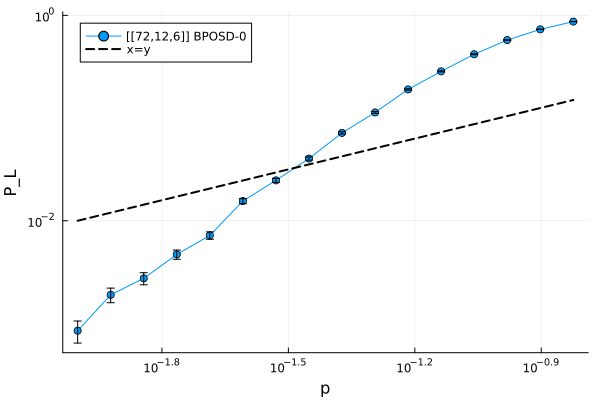

In [5]:
function get_curve(dict_obj, p_range)
    return [dict_obj[p] for p in p_range]
end

p_fail_sorted = get_curve(p_fail_list, p_range)
yerr = sqrt.(p_fail_sorted .* (1 .- p_fail_sorted) ./ num_total_samples)

g = plot(xscale = :log10, yscale = :log10)
plot!(p_range, p_fail_sorted;
    label = "$(spec.label) BPOSD-0",
    marker = :circle,
    yerr = yerr,
)
plot!(p_range, p_range; label = "x=y", ls = :dash, lw = 2, color = :black)
plot!(xlabel = "p", ylabel = "P_L", legend = :topleft)


## [[108,8,10]]

In [6]:
type_lattice = "bb_108_8_10"

spec, fn, p_fail_list = run_type_lattice(type_lattice)

(label = "[[108,8,10]]", l = 9, m = 6, A_terms = [(:x, 3), (:y, 1), (:y, 2)], B_terms = [(:y, 3), (:x, 1), (:x, 2)])
      From worker 2:	["1/16, p=0.01, 2.355598042, 2026-03-28T22:45:10.261"]
      From worker 2:	["2/16, p=0.011978600582696366, 1.498574625, 2026-03-28T22:45:11.773"]
      From worker 2:	["3/16, p=0.014348687191977362, 1.455831083, 2026-03-28T22:45:13.234"]
      From worker 2:	["4/16, p=0.01718771927587479, 1.838662084, 2026-03-28T22:45:15.086"]
      From worker 2:	["5/16, p=0.02058848241332152, 2.192377917, 2026-03-28T22:45:17.300"]
      From worker 2:	["6/16, p=0.0246621207433047, 1.973031209, 2026-03-28T22:45:19.284"]
      From worker 2:	["7/16, p=0.02954176939062777, 2.056015917, 2026-03-28T22:45:21.382"]
      From worker 2:	["8/16, p=0.03538690560364554, 2.347756667, 2026-03-28T22:45:23.760"]
      From worker 2:	["9/16, p=0.04238856080836498, 2.797946375, 2026-03-28T22:45:26.570"]
      From worker 2:	["10/16, p=0.050775563919874075, 5.349277333, 2026-03-28T

((label = "[[108,8,10]]", l = 9, m = 6, A_terms = [(:x, 3), (:y, 1), (:y, 2)], B_terms = [(:y, 3), (:x, 1), (:x, 2)]), "bb_108_8_10_bposd0_0.01_0.15_20000.jld2", Dict(0.08727161387290322 => 0.31155, 0.011978600582696366 => 0.0007000000000000339, 0.10453918047908103 => 0.4979, 0.0246621207433047 => 0.005249999999999977, 0.01718771927587479 => 0.0010000000000000009, 0.02954176939062777 => 0.011099999999999999, 0.050775563919874075 => 0.054950000000000054, 0.01 => 0.00039999999999995595, 0.03538690560364554 => 0.016750000000000043, 0.04238856080836498 => 0.02849999999999997…))

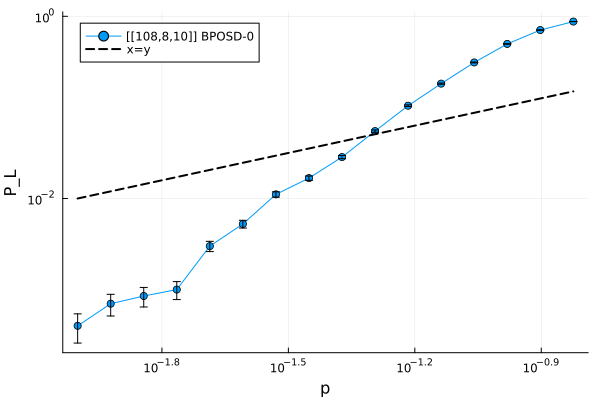

In [7]:
p_fail_sorted = get_curve(p_fail_list, p_range)
yerr = sqrt.(p_fail_sorted .* (1 .- p_fail_sorted) ./ num_total_samples)

g = plot(xscale = :log10, yscale = :log10)
plot!(p_range, p_fail_sorted;
    label = "$(spec.label) BPOSD-0",
    marker = :circle,
    yerr = yerr,
)
plot!(p_range, p_range; label = "x=y", ls = :dash, lw = 2, color = :black)
plot!(xlabel = "p", ylabel = "P_L", legend = :topleft)

## [[144, 12, 12]]

In [8]:
type_lattice = "bb_144_12_12"

spec, fn, p_fail_list = run_type_lattice(type_lattice)

(label = "[[144,12,12]]", l = 12, m = 6, A_terms = [(:x, 3), (:y, 1), (:y, 2)], B_terms = [(:y, 3), (:x, 1), (:x, 2)])
      From worker 2:	["1/16, p=0.01, 2.638640209, 2026-03-28T22:49:37.334"]
      From worker 2:	["2/16, p=0.011978600582696366, 2.253053458, 2026-03-28T22:49:39.595"]
      From worker 2:	["3/16, p=0.014348687191977362, 2.714660459, 2026-03-28T22:49:42.328"]
      From worker 2:	["4/16, p=0.01718771927587479, 2.935222875, 2026-03-28T22:49:45.275"]
      From worker 2:	["5/16, p=0.02058848241332152, 3.128333125, 2026-03-28T22:49:48.424"]
      From worker 2:	["6/16, p=0.0246621207433047, 3.03028225, 2026-03-28T22:49:51.494"]
      From worker 2:	["7/16, p=0.02954176939062777, 3.314619458, 2026-03-28T22:49:54.820"]
      From worker 2:	["8/16, p=0.03538690560364554, 3.661508583, 2026-03-28T22:49:58.490"]
      From worker 2:	["9/16, p=0.04238856080836498, 4.293900334, 2026-03-28T22:50:02.796"]
      From worker 2:	["10/16, p=0.050775563919874075, 6.483276125, 2026-03-28

((label = "[[144,12,12]]", l = 12, m = 6, A_terms = [(:x, 3), (:y, 1), (:y, 2)], B_terms = [(:y, 3), (:x, 1), (:x, 2)]), "bb_144_12_12_bposd0_0.01_0.15_20000.jld2", Dict(0.08727161387290322 => 0.3457, 0.011978600582696366 => 0.0007500000000000284, 0.10453918047908103 => 0.5458000000000001, 0.0246621207433047 => 0.005600000000000049, 0.01718771927587479 => 0.0020000000000000018, 0.02954176939062777 => 0.011950000000000016, 0.050775563919874075 => 0.05854999999999999, 0.01 => 0.00044999999999995044, 0.03538690560364554 => 0.019299999999999984, 0.04238856080836498 => 0.03359999999999996…))

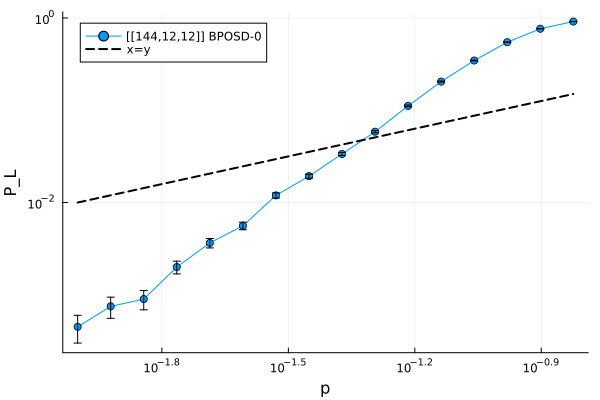

In [9]:
p_fail_sorted = get_curve(p_fail_list, p_range)
yerr = sqrt.(p_fail_sorted .* (1 .- p_fail_sorted) ./ num_total_samples)

g = plot(xscale = :log10, yscale = :log10)
plot!(p_range, p_fail_sorted;
    label = "$(spec.label) BPOSD-0",
    marker = :circle,
    yerr = yerr,
)
plot!(p_range, p_range; label = "x=y", ls = :dash, lw = 2, color = :black)
plot!(xlabel = "p", ylabel = "P_L", legend = :topleft)

## plot the 3 codes together

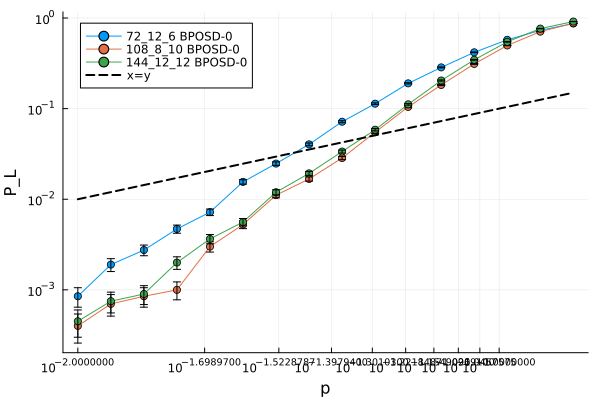

In [10]:
type_lattices = ["72_12_6", "108_8_10", "144_12_12"]
results = [load("bb_$(type_lattice)_bposd0_0.01_0.15_20000.jld2") for type_lattice in type_lattices]
p_fail_sorted_lists = [get_curve(res["p_fail_list"], p_range) for res in results]


g = plot(xscale = :log10, yscale = :log10)

for (type_lattice, p_fail_sorted) in zip(type_lattices, p_fail_sorted_lists)
    yerr = sqrt.(p_fail_sorted .* (1 .- p_fail_sorted) ./ num_total_samples)
    plot!(p_range, p_fail_sorted;
        label = "$(type_lattice) BPOSD-0",
        marker = :circle,
        yerr=yerr,
    )
end
plot!(p_range, p_range; label = "x=y", ls = :dash, lw = 2, color = :black)
plot!(xlabel = "p", ylabel = "P_L", legend = :topleft)
plot!(yticks=[1, 1e-1, 1e-2, 1e-3], xticks= 1e-2 .* (1:10))
